In [3]:
import earthaccess
import xarray as xr
from xarray.backends.api import open_datatree
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import matplotlib.animation as animation
import os
import re
from datetime import datetime


In [4]:
import earthaccess,csv
import xarray as xr
from xarray.backends.api import open_datatree
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
from scipy.ndimage import generic_filter
from scipy.ndimage import gaussian_filter
from scipy.interpolate import griddata
from scipy.ndimage import median_filter
from scipy.interpolate import LinearNDInterpolator
from scipy.ndimage import generic_filter
from scipy.stats import binned_statistic_2d

In [5]:
%pip install jaxparrow
from jaxparrow import cyclogeostrophy
from jaxparrow import geostrophy
import jax.numpy as jnp
import jaxparrow as jxr

Note: you may need to restart the kernel to use updated packages.


In [6]:
auth = earthaccess.login(persist=True)

In [7]:
# Inputs
# your desired range. currently, NEUROST date indexing is wrong
t1 = datetime(2024,5,8)
t2 = datetime(2024,5,8)
date_requested='20240508'
pacedate="2024-05-08"
k=37.5
j=33.7
kk=293
jj=286

# t1 = datetime(2024,6,1)
# t2 = datetime(2024,6,1)
# date_requested='20240601'
# pacedate="2024-06-01"

# t1 = datetime(2024,4,14)
# t2 = t1
# date_requested='20240414'
# pacedate="2024-04-14"

In [8]:
# moana_ds

In [9]:
moana_ds = xr.open_dataset('data/moana_Edward_05082024.nc') # should rename this with file extention .ncs
mlon = moana_ds.variables['longitude'] + 360
mlat = moana_ds.variables['latitude'] 
pro = moana_ds.variables['prococcus_moana']
pico = moana_ds.variables['picoeuk_moana'] 
syn = moana_ds.variables['syncoccus_moana'] 
chl= moana_ds.variables['chlor_a'] 
poc= moana_ds.variables['poc'] 

# moana_location='data/moana/' # should rename this with file extention .ncs
# # file='PACE_OCI.20240414T165338.L2_MOANA.V3.nc'
# file='PACE_OCI.20240601T165222.L2_MOANA.V3.nc'

# datatree = open_datatree(moana_location + file)
# dataset = xr.merge(datatree.to_dict().values())
# moanads = dataset.set_coords(("longitude", "latitude"))
# h=str(file)
# sat_date=h[9:17]
# del datatree

# mlon = moanads.variables['longitude']+360
# mlat = moanads.variables['latitude'] 
# pro = moanads.variables['prococcus_moana']
# pico = moanads.variables['picoeuk_moana'] 
# syn = moanads.variables['syncoccus_moana'] 
# chla = moanads.variables['chlor_a'] 
# poc = moanads.variables['poc']
# chl=chla
# mlon,mlat=np.meshgrid()

In [10]:
# chl=chla

In [11]:
tspan = ("2023-01-01", "2023-01-30")
# tspan2 = ("2024-06-27", "2024-06-27")
bbox = (-73, 34, -70, 37.5) #edward
clouds = (0, 100)

In [12]:
# pattern = f"PACE_OCI.{date_requested}T*.L2_MOANA.V3.nc"
# files = glob.glob(os.path.join(moana_dir, pattern))
# files
# moana=files[0]

In [13]:
aviso_ds = xr.open_dataset('/home/jovyan/go-swace/data/eddy_trajectories/Edward_Eddy_trajectory_nrt_3.2exp_cyclonic_20180101_20240723.nc')
aviso_ds

<xarray.Dataset> Size: 202kB
Dimensions:                        (obs: 223, NbSample: 20)
Dimensions without coordinates: obs, NbSample
Data variables: (12/27)
    amplitude                      (obs) float64 2kB ...
    effective_area                 (obs) float32 892B ...
    effective_contour_height       (obs) float32 892B ...
    effective_contour_latitude     (obs, NbSample) float64 36kB ...
    effective_contour_longitude    (obs, NbSample) float64 36kB ...
    effective_contour_shape_error  (obs) float64 2kB ...
    ...                             ...
    speed_contour_longitude        (obs, NbSample) float64 36kB ...
    speed_contour_shape_error      (obs) float64 2kB ...
    speed_radius                   (obs) float64 2kB ...
    time                           (obs) datetime64[ns] 2kB ...
    track                          (obs) uint32 892B ...
    uavg_profile                   (obs, NbSample) float64 36kB ...
Attributes: (12/19)
    Metadata_Conventions:      Unidata Dataset Discovery v1.0
    comment:                   Surface product; mesoscale eddies
    creator_email:             aviso@altimetry.fr
    creator_url:               https://www.aviso.altimetry.fr
    date_created:              2024-08-06T09:38:06Z
    framework_used:            https://github.com/AntSimi/py-eddy-tracker
    ...                        ...
    standard_name_vocabulary:  NetCDF Climate and Forecast (CF) Metadata Conv...
    summary:                   This dataset contains eddy atlas from all-sate...
    time_coverage_duration:    P2396D
    time_coverage_end:         2024-07-23T00:00:00Z
    time_coverage_start:       2018-01-01T00:00:00Z
    title:                     Mesoscale Cyclonic Eddies in Altimeter Observa...

In [14]:
def get_eddy_by_ID_date(ds,eddy_date):
    """
    ds: netCDF AVISO format
    track_id: id of eddy to extract
    eddy_date: date in format 'YYYY-MM-DD'

    Returns contour lons, contour lats, center lon, center lat
    """
    try:
        ind = np.where(ds.time == np.datetime64(eddy_date))[0][0]
        contour_lons = np.array(ds.effective_contour_longitude[ind])
        contour_lats = np.array(ds.effective_contour_latitude[ind])
    except:
        print('No eddy data available with that request ... :(')        
    
    return contour_lons,contour_lats,ds.longitude[ind],ds.latitude[ind]

In [15]:
contour_lons, contour_lats, _, _ = get_eddy_by_ID_date(aviso_ds, t1)

In [16]:
results = earthaccess.search_data(
    short_name="NEUROST_SSH-SST_L4_V2024.0",
    temporal=tspan)

In [17]:
paths = earthaccess.open(results) #'streaming' data

QUEUEING TASKS | :   0%|          | 0/532 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/532 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/532 [00:00<?, ?it/s]

In [18]:
# parse only the FIRST date (analysis date)

#account for issues in NEUROST indexing
fname_pattern = re.compile(r"NeurOST_SSH-SST_(\d{8})_\d{8}\.nc", re.IGNORECASE)

def extract_analysis_date(fname):
    m = fname_pattern.search(fname)
    if not m:
        return None
    return datetime.strptime(m.group(1), "%Y%m%d")

filtered = []
for obj in paths:
    s = str(obj)

    # extract filename from repr
    m = fname_pattern.search(s)
    if not m:
        continue

    date = datetime.strptime(m.group(1), "%Y%m%d")

    if t1 <= date <= t2:
        filtered.append(obj)

print("Matched:", len(filtered), "files")

Matched: 1 files


In [19]:
filtered

[<File-like object S3FileSystem, podaac-ops-cumulus-protected/NEUROST_SSH-SST_L4_V2024.0/NeurOST_SSH-SST_20240508_20241126.nc>]

In [20]:
filtered[0]

<File-like object S3FileSystem, podaac-ops-cumulus-protected/NEUROST_SSH-SST_L4_V2024.0/NeurOST_SSH-SST_20240508_20241126.nc>

In [21]:
dataset = xr.open_dataset(filtered[0]) #for netcdf

In [22]:
dataset

<xarray.Dataset> Size: 194MB
Dimensions:                 (latitude: 1500, longitude: 3600, time: 1)
Coordinates:
  * longitude               (longitude) float64 29kB 0.1 0.2 0.3 ... 359.9 360.0
  * latitude                (latitude) float64 12kB -70.0 -69.9 ... 79.8 79.9
  * time                    (time) datetime64[ns] 8B 2024-05-08
    Lambert_Azimuthal_Grid  int32 4B ...
Data variables:
    sla                     (latitude, longitude, time) float32 22MB ...
    adt                     (latitude, longitude, time) float32 22MB ...
    ugosa                   (latitude, longitude, time) float32 22MB ...
    vgosa                   (latitude, longitude, time) float32 22MB ...
    sn                      (latitude, longitude, time) float32 22MB ...
    ss                      (latitude, longitude, time) float32 22MB ...
    zeta                    (latitude, longitude, time) float32 22MB ...
    ugos                    (latitude, longitude, time) float32 22MB ...
    vgos                    (latitude, longitude, time) float32 22MB ...
Attributes: (12/37)
    title:                      Daily NeurOST (SSH-SST) Sea Surface Height an...
    summary:                    A mapped level 4 sea surface height analysis ...
    Conventions:                CF-1.10
    standard_name_vocabulary:   NetCDF Climate and Forecast (CF) Metadata Con...
    keywords:                   Oceans > Sea Surface Topography > Sea Surface...
    keywords_vocabulary:        NASA Global Change Master Directory (GCMD) Sc...
    ...                         ...
    creator_url:                http://podaac.jpl.nasa.gov
    publisher_name:             JPL PO.DAAC
    publisher_url:              http://podaac.jpl.nasa.gov
    date_created:               2024-11-26T14:33:55.633872
    references:                 https://doi.org/10.31223/X5W676 and https://d...
    comment:                    NeurOST = Neural Ocean Surface Topography. Ne...

In [23]:
# bbox = (-80, 32, -40, 42)

In [24]:
mask = (dataset.longitude >= bbox[0]) & (dataset.longitude <= bbox[2]) & (dataset.latitude >= bbox[1]) & (dataset.latitude <= bbox[3])
if mask.sum() == 0:
    mask = (dataset.longitude >= bbox[0]) & (dataset.longitude <= bbox[2])
    if mask.sum() == 0:
        print('Mask via longitude only')
        mask = (dataset.latitude >= bbox[1]) & (dataset.latitude <= bbox[3])
        print(mask.sum())
    else:
        print('Mask via latitude only')

Mask via longitude only
<xarray.DataArray 'latitude' ()> Size: 8B
array(35)
Coordinates:
    Lambert_Azimuthal_Grid  int32 4B -2147483647


In [25]:
dataset = dataset.where(mask, drop=True)

In [26]:
lon=dataset["longitude"].values
lat=dataset["latitude"].values
ug=dataset["ugos"].values
vg=dataset["vgos"].values

np.shape(ug)

# plt.streamplot(x=lon, y=lat, u=ug, v=vg, density = 2, color = (0.2,0.2,0.2,0.6))

(35, 3600, 1)

In [27]:
# Compare geostrophic vorticity with vorticity calculated from cyclogeostrophic currents
def compute_normalized_vorticity_strain_neurost(data_array,u,v,wfl):

    lat1d=data_array.latitude.values
    lon1d=data_array.longitude.values
    Lon2D, Lat2D = np.meshgrid(lon1d, lat1d)
    lats = jnp.array(Lat2D)
    lons = jnp.array(Lon2D)

    dx, dy = jxr.tools.geometry.compute_spatial_step(lats, lons)
    mask = np.zeros_like(u)

    #Smoothing code is under construction here... this snippet of smoothing code written with help of AI (as you can likely tell...)
    #I'm still trying to figure out why just simply running the generic filter on u and v is cutting the swath substantially, whereas this code retains swath width...
    #I'll come back to this, but it does work well for now.
    def direct_2d_swath_smoothing(u_geos_u, lat, lon, window_size=5, angle_tolerance=30):
        """
        Modified version of your original code for 2D smoothing
        """
        # Calculate track direction (same as original)
        dy = np.gradient(lat, axis=0)
        dx = np.gradient(lon, axis=0)
        
        with np.errstate(divide='ignore', invalid='ignore'):
            track_angle = np.arctan2(dy, dx)
            track_angle = np.nan_to_num(track_angle, nan=0.0)
        
        # Use the same window size for both directions
        footprint = np.ones((window_size, window_size), dtype=bool)
        
        def simple_2d_filter(values):
            """Simplified 2D version of your original filter"""
            center_idx = len(values) // 2
            if np.isnan(values[center_idx]):
                return np.nan
            
            # Get center point's track angle
            center_angle = track_angle.flat[center_idx]
            
            # Calculate angular differences
            window_angles = track_angle.flat[:len(values)]
            angle_diffs = np.abs(window_angles - center_angle)
            angle_diffs = np.minimum(angle_diffs, 2*np.pi - angle_diffs)
            
            # Create mask for points along track
            along_track_mask = angle_diffs < np.radians(angle_tolerance)
            valid_mask = ~np.isnan(values)
            
            # Use ALL valid points along track (no distance weighting)
            final_mask = along_track_mask & valid_mask
            
            if np.any(final_mask):
                return np.mean(values[final_mask])  # Simple average
            else:
                return values[center_idx]
    
        smoothed = generic_filter(u_geos_u, simple_2d_filter, footprint=footprint, mode='nearest', cval=np.nan)
        # Apply the filter (this now does 2D smoothing following swath direction)
        return smoothed
   
    # u=generic_filter(u, np.mean, size=[wfl,wfl], mode='nearest')
    # v=generic_filter(v, np.mean, size=[wfl,wfl], mode='nearest')

    u=direct_2d_swath_smoothing(u, lats, lons, window_size=wfl)
    v=direct_2d_swath_smoothing(v, lats, lons, window_size=wfl)

    # Compute derivatives
    dv_dx = jxr.tools.operators.derivative(v, dx, mask=mask, axis=1, padding="right")  # ∂v/∂x
    du_dy = jxr.tools.operators.derivative(u, dy, mask=mask, axis=0, padding="right")  # ∂u/∂y

    du_dx = jxr.tools.operators.derivative(u, dx, mask=mask, axis=1, padding="right")  # ∂v/∂x
    dv_dy = jxr.tools.operators.derivative(v, dy, mask=mask, axis=0, padding="right")  # ∂u/∂y

    #Compute coriolis for normalization
    omega = 7.2921159e-05  # angular velocity of the Earth [rad/s]
    fc = 2*omega*np.sin(lats*np.pi/180.)
        
    # avoid zero near equator, bound fc by min val as 1.e-8
    f_coriolis = np.sign(fc)*np.maximum(np.abs(fc), 1.e-8)

    vorticity = dv_dx - du_dy / f_coriolis
    strain= np.sqrt((du_dx - dv_dy)**2 + (du_dy + dv_dx) ** 2)
    strain=jnp.array(strain)/f_coriolis 
    OkuboWeiss=(du_dx - dv_dy)**2 + (du_dy + dv_dx) ** 2 - (dv_dx - du_dy) ** 2 #double check and propagate to other scripts
    OkuboWeiss=OkuboWeiss/4

    return vorticity,strain,OkuboWeiss

In [28]:
dataset.latitude.values

array([34.1, 34.2, 34.3, 34.4, 34.5, 34.6, 34.7, 34.8, 34.9, 35. , 35.1,
       35.2, 35.3, 35.4, 35.5, 35.6, 35.7, 35.8, 35.9, 36. , 36.1, 36.2,
       36.3, 36.4, 36.5, 36.6, 36.7, 36.8, 36.9, 37. , 37.1, 37.2, 37.3,
       37.4, 37.5])

In [29]:
dataset

<xarray.Dataset> Size: 5MB
Dimensions:                 (latitude: 35, longitude: 3600, time: 1)
Coordinates:
  * longitude               (longitude) float64 29kB 0.1 0.2 0.3 ... 359.9 360.0
  * latitude                (latitude) float64 280B 34.1 34.2 34.3 ... 37.4 37.5
  * time                    (time) datetime64[ns] 8B 2024-05-08
    Lambert_Azimuthal_Grid  int32 4B -2147483647
Data variables:
    sla                     (latitude, longitude, time) float32 504kB nan ......
    adt                     (latitude, longitude, time) float32 504kB nan ......
    ugosa                   (latitude, longitude, time) float32 504kB nan ......
    vgosa                   (latitude, longitude, time) float32 504kB nan ......
    sn                      (latitude, longitude, time) float32 504kB nan ......
    ss                      (latitude, longitude, time) float32 504kB nan ......
    zeta                    (latitude, longitude, time) float32 504kB nan ......
    ugos                    (latitude, longitude, time) float32 504kB nan ......
    vgos                    (latitude, longitude, time) float32 504kB nan ......
Attributes: (12/37)
    title:                      Daily NeurOST (SSH-SST) Sea Surface Height an...
    summary:                    A mapped level 4 sea surface height analysis ...
    Conventions:                CF-1.10
    standard_name_vocabulary:   NetCDF Climate and Forecast (CF) Metadata Con...
    keywords:                   Oceans > Sea Surface Topography > Sea Surface...
    keywords_vocabulary:        NASA Global Change Master Directory (GCMD) Sc...
    ...                         ...
    creator_url:                http://podaac.jpl.nasa.gov
    publisher_name:             JPL PO.DAAC
    publisher_url:              http://podaac.jpl.nasa.gov
    date_created:               2024-11-26T14:33:55.633872
    references:                 https://doi.org/10.31223/X5W676 and https://d...
    comment:                    NeurOST = Neural Ocean Surface Topography. Ne...

In [30]:
np.shape(ug)

(35, 3600, 1)

In [31]:
vort,strain,OkuboWeiss=compute_normalized_vorticity_strain_neurost(dataset,np.squeeze(ug),np.squeeze(vg),8)

(33.7, 39.0)

<Figure size 640x480 with 0 Axes>

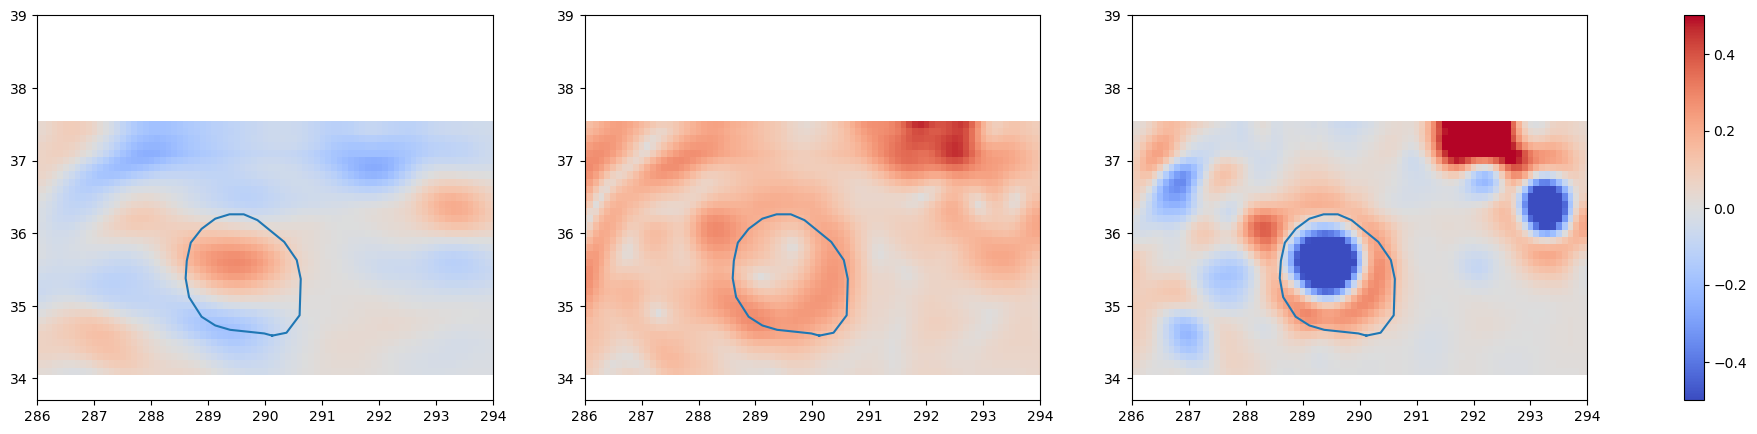

In [32]:
vel=0.5
plt.clf()

fig,ax=plt.subplots(1,3,figsize=(25,5))

plot = ax[0].pcolormesh(dataset.longitude,dataset.latitude,vort,cmap='coolwarm',vmin=-vel,vmax=vel)
# cbar = plt.colorbar(plot,ax=ax)
# cbar.set_label('vorticity/f', rotation=270, labelpad=15)
ax[0].plot(contour_lons,contour_lats)
plot = ax[1].pcolormesh(dataset.longitude,dataset.latitude,strain,cmap='coolwarm',vmin=-vel,vmax=vel)
cbar = plt.colorbar(plot,ax=ax)
ax[1].plot(contour_lons,contour_lats)

vel=2e-10
plot = ax[2].pcolormesh(dataset.longitude,dataset.latitude,OkuboWeiss,cmap='coolwarm',vmin=-vel,vmax=vel)
plt.plot(contour_lons,contour_lats)

# cbar.set_label('strain/f', rotation=270, labelpad=15)
ax[0].set_xlim([286,294])
ax[0].set_ylim([33.7,39])
ax[1].set_xlim([286,294])
ax[1].set_ylim([33.7,39 ])
ax[2].set_xlim([286,294])
ax[2].set_ylim([33.7,39 ])

In [33]:
### relationships with PACE

In [34]:
# Let's interpolate MOANA onto SWOT Level-2 grids for each swot dataset
# This will take a long time!
# pro = griddata((mlon.values.ravel(),mlat.values.ravel()), pro.values.ravel(), (Lon2D, Lat2D), method='linear')
# pico = griddata((mlon.values.ravel(),mlat.values.ravel()), pico.values.ravel(), (Lon2D, Lat2D), method='linear')
# syn = griddata((mlon.values.ravel(),mlat.values.ravel()), syn.values.ravel(), (Lon2D, Lat2D), method='linear')
# chl = griddata((mlon.values.ravel(),mlat.values.ravel()), chl.values.ravel(), (Lon2D, Lat2D), method='linear')

In [35]:
# pro = griddata((mlon.values.ravel(),mlat.values.ravel()), pro.values.flatten(), (Lon2D, Lat2D), method='linear')
# pico = griddata((mlon.values.ravel(),mlat.values.ravel()), pico.values.flatten(), (Lon2D, Lat2D), method='linear')
# syn = griddata((mlon.values.ravel(),mlat.values.ravel()), syn.values.flatten(), (Lon2D, Lat2D), method='linear')
# chl = griddata((mlon.values.ravel(),mlat.values.ravel()), chl.values.flatten(), (Lon2D, Lat2D), method='linear')

### SST

In [36]:
tspan = (pacedate,pacedate) 
results = earthaccess.search_data(
    short_name='L3S_LEO_DY-STAR-v2.81',
    bounding_box=bbox,
    temporal=tspan,
)

In [37]:
paths = earthaccess.open(results) #'streaming' data

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

In [38]:
# bbox=(-73,34,-65,37.5)
bbox=(jj-360,j,kk-360,k)


In [39]:
datatree = xr.open_datatree(paths[0])  

# Merge
dsmerge = xr.merge(datatree.to_dict().values())
dsmerge = dsmerge.set_coords(("lon", "lat"))

/tmp/ipykernel_1346/1422747284.py:1: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  datatree = xr.open_datatree(paths[0])


In [40]:
# Bounding box: [min_lon, min_lat, max_lon, max_lat]
min_lon, min_lat, max_lon, max_lat = bbox

# Check latitude ordering
if dsmerge.lat[0] > dsmerge.lat[-1]:  # Descending (e.g., 90 to -90)
    lat_slice = slice(max_lat, min_lat)
else:  # Ascending (e.g., -90 to 90)
    lat_slice = slice(min_lat, max_lat)

# Longitude is almost always ascending (e.g., -180 to 180)
lon_slice = slice(min_lon, max_lon)

# Crop using xarray's efficient selection
sstdata = dsmerge.sel(lon=lon_slice, lat=lat_slice)

# That's it! The cropped dataset is ready

In [41]:
sstdata

<xarray.Dataset> Size: 5MB
Dimensions:                  (time: 1, lat: 190, lon: 350)
Coordinates:
  * lat                      (lat) float32 760B 37.49 37.47 ... 33.73 33.71
  * lon                      (lon) float32 1kB -73.99 -73.97 ... -67.03 -67.01
  * time                     (time) datetime64[ns] 8B 2024-05-08T12:00:00
Data variables: (12/17)
    sea_surface_temperature  (time, lat, lon) float32 266kB ...
    sses_bias                (time, lat, lon) float32 266kB ...
    sses_standard_deviation  (time, lat, lon) float32 266kB ...
    l2p_flags                (time, lat, lon) int16 133kB ...
    l3s_flags                (time, lat, lon) float32 266kB ...
    sst_count                (time, lat, lon) float32 266kB ...
    ...                       ...
    wind_speed               (time, lat, lon) float32 266kB ...
    sst_dtime                (time, lat, lon) timedelta64[ns] 532kB ...
    measurement_dtime        (time, lat, lon) timedelta64[ns] 532kB ...
    crs                      int32 4B ...
    sst_gradient_magnitude   (time, lat, lon) float32 266kB ...
    sst_front_position       (time, lat, lon) float32 266kB ...
Attributes: (12/58)
    collation_version:          2.11.0
    start_time:                 20240508T000000Z
    time_coverage_start:        20240508T000000Z
    stop_time:                  20240508T235959Z
    time_coverage_end:          20240508T235959Z
    date_created:               20241010T220619Z
    ...                         ...
    geospatial_lon_min:         -179.99
    geospatial_lon_max:         179.99
    geospatial_lat_min:         -89.99
    geospatial_lat_max:         89.99
    netcdf_version_id:          4.7.4
    uuid:                       745a14d1-d894-4ea2-9dcc-add400d069f0

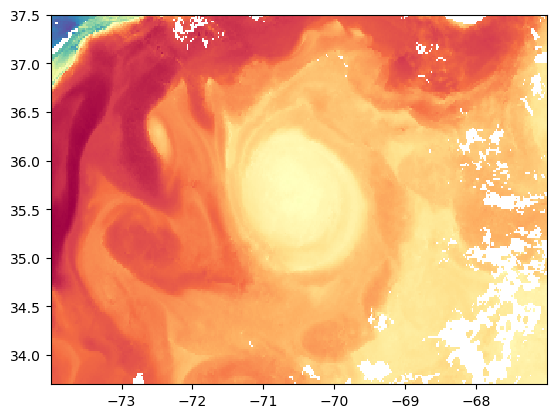

In [42]:
plt.pcolormesh(sstdata['lon'],sstdata['lat'],np.squeeze(sstdata['sea_surface_temperature']),cmap='Spectral_r')

In [43]:
sst=sstdata['sea_surface_temperature']-273.15

In [44]:
sst

<xarray.DataArray 'sea_surface_temperature' (time: 1, lat: 190, lon: 350)> Size: 266kB
array([[[14.170013, 14.320007, 14.279999, ...,       nan,       nan,
         22.609985],
        [14.149994, 14.160004, 14.019989, ..., 22.440002,       nan,
         22.220001],
        [14.      , 14.019989, 13.829987, ..., 22.380005, 22.339996,
         22.179993],
        ...,
        [24.109985, 24.109985, 24.100006, ..., 20.25    , 20.190002,
         20.089996],
        [24.130005, 24.079987, 24.049988, ..., 20.209991, 20.119995,
         20.040009],
        [24.100006, 24.019989, 24.01001 , ..., 20.160004, 20.139984,
         20.089996]]], shape=(1, 190, 350), dtype=float32)
Coordinates:
  * lat      (lat) float32 760B 37.49 37.47 37.45 37.43 ... 33.75 33.73 33.71
  * lon      (lon) float32 1kB -73.99 -73.97 -73.95 ... -67.05 -67.03 -67.01
  * time     (time) datetime64[ns] 8B 2024-05-08T12:00:00

/tmp/ipykernel_1346/359981732.py:11: UserWarning: The input coordinates to pcolor are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolor.
  plot = ax[0,0].pcolor(mlon,mlat,np.log10(chl),cmap='Spectral_r',vmin=-1.1,vmax=-0.5)
/tmp/ipykernel_1346/359981732.py:13: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(plot,ax=ax[0,0])
/tmp/ipykernel_1346/359981732.py:25: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plot = ax[1,0].pcolormesh(mlon,mlat,np.log10(pico),cmap='Spect

<Figure size 640x480 with 0 Axes>

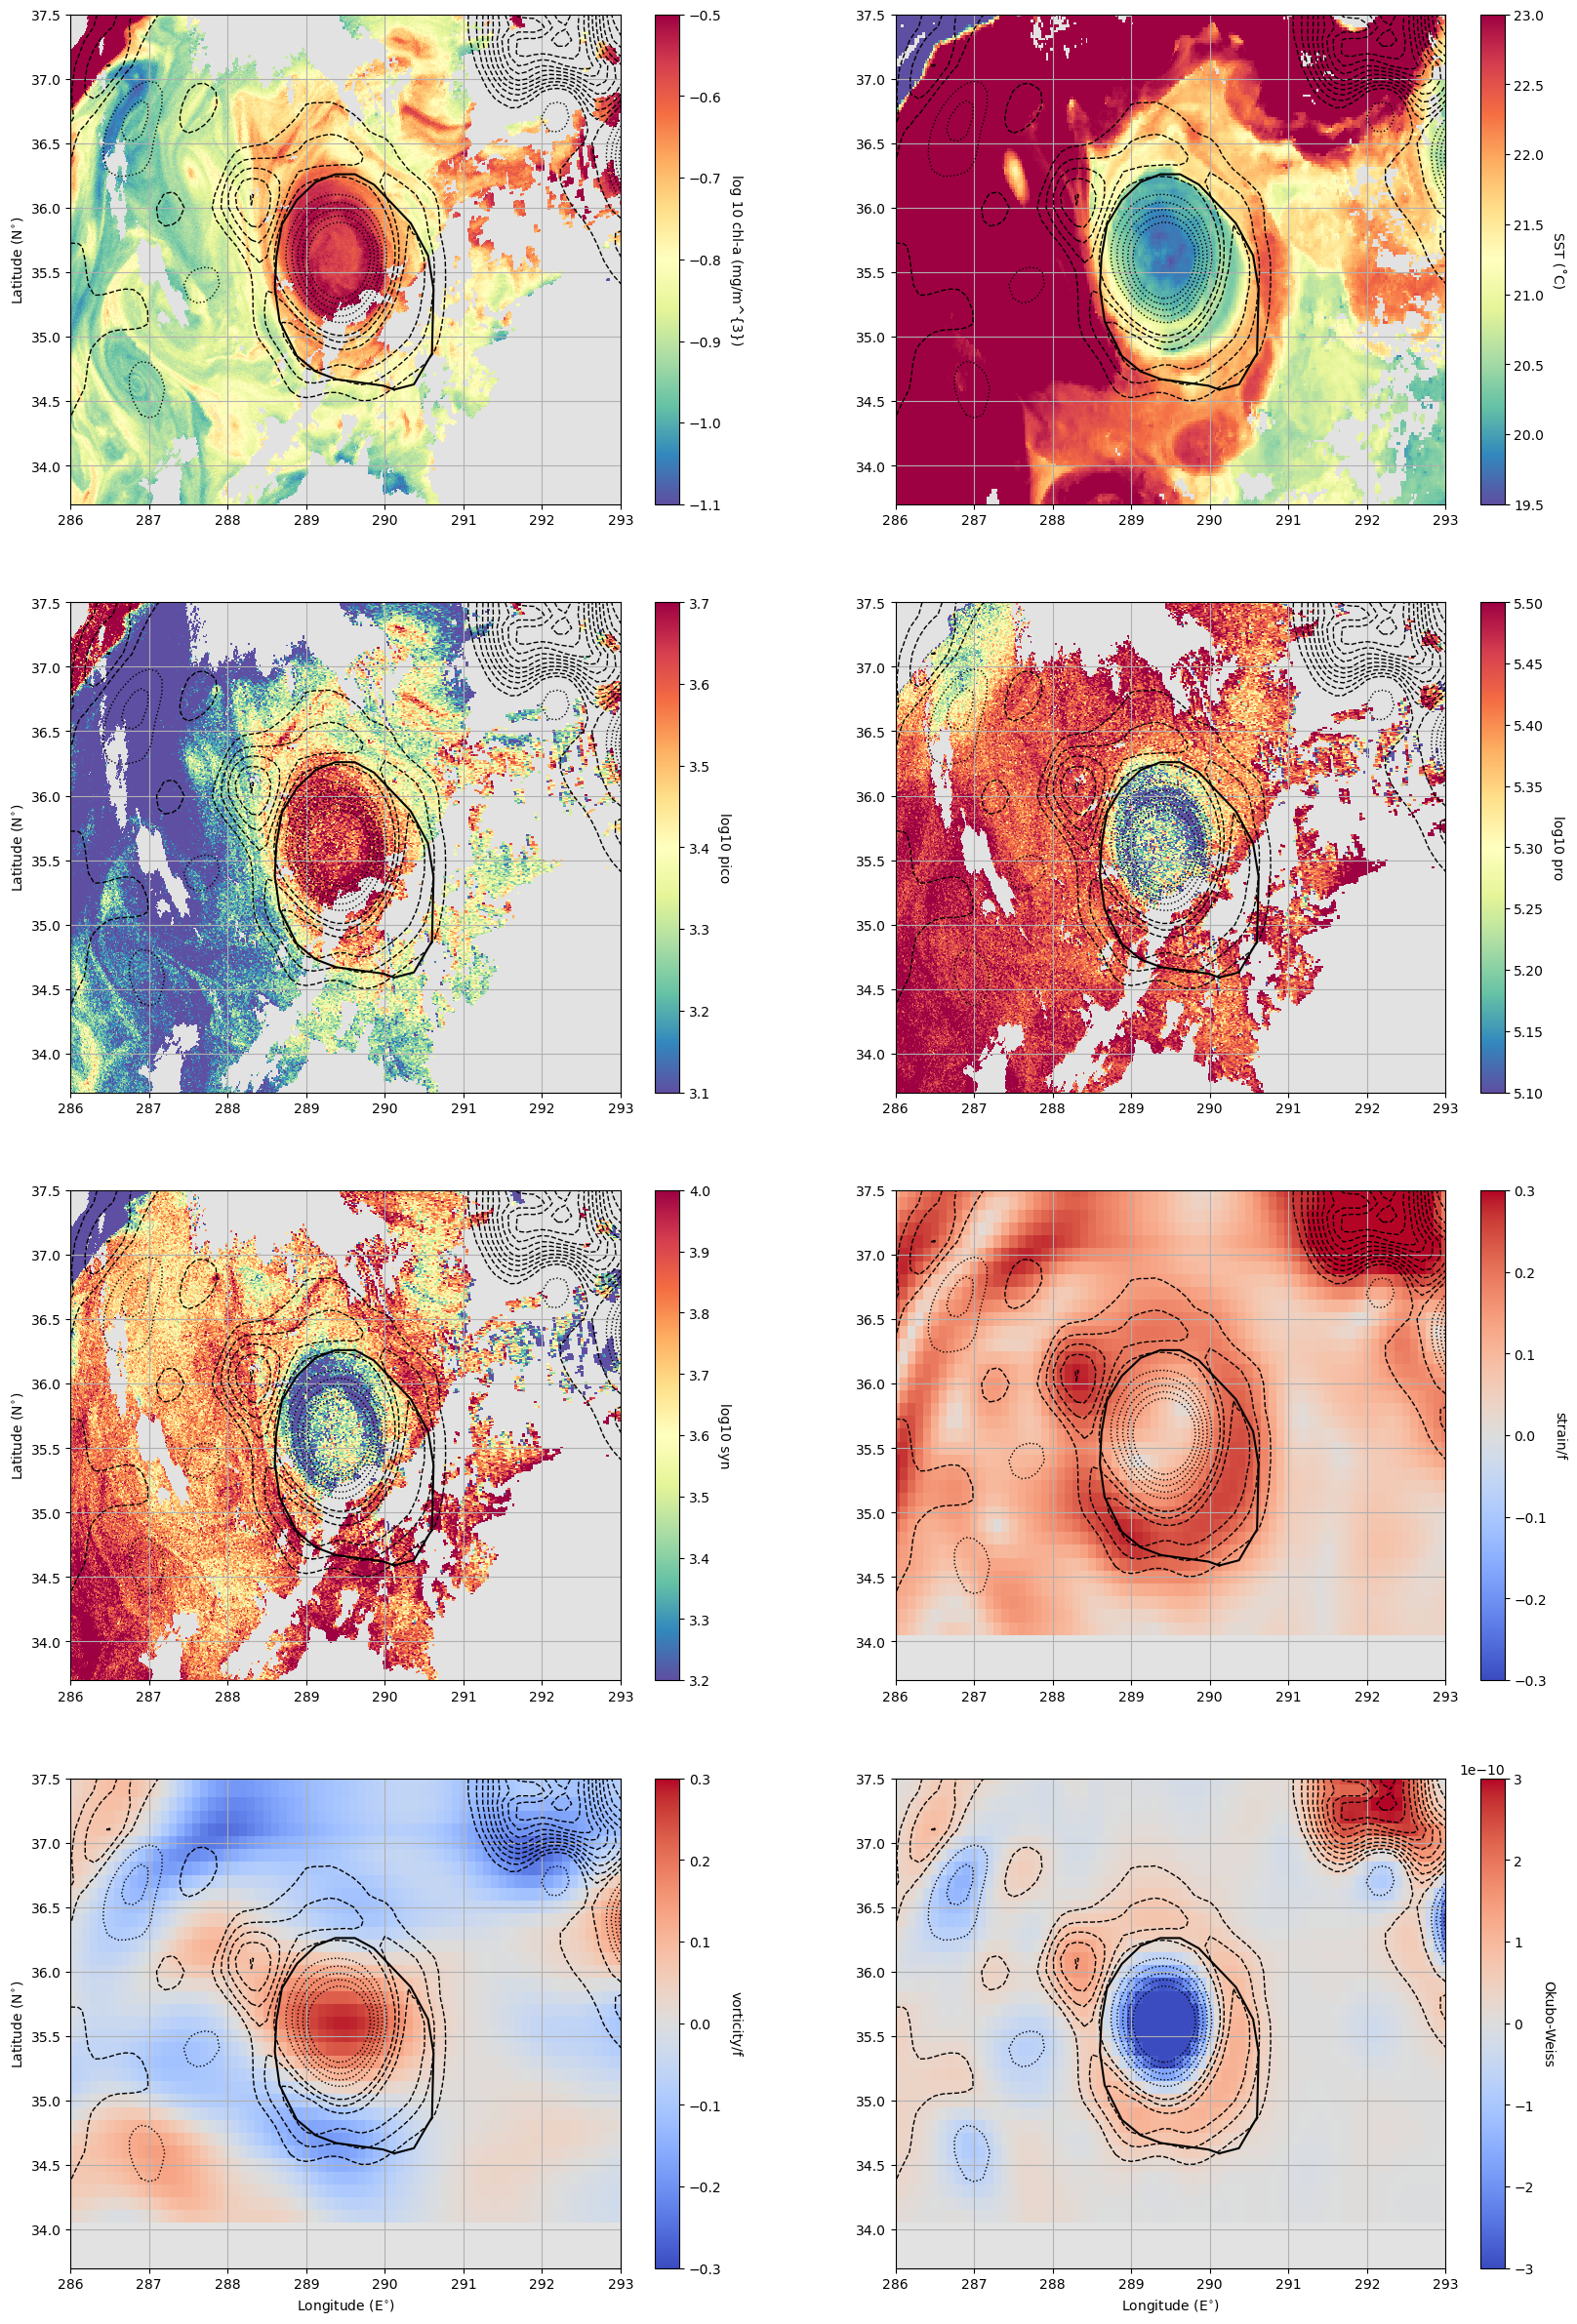

In [83]:
lon1d=dataset.longitude
lat1d=dataset.latitude
vel=0.3
plt.clf()

fig,ax=plt.subplots(4,2,figsize=(20,30))

# plot = ax[0].pcolormesh(lon1d,lat1d,chl,cmap='Spectral_r',vmin=-0,vmax=0.3)
# plot = ax[0,0].pcolor(mlon,mlat,chl,cmap='Spectral_r',vmin=0.2,vmax=0.5)
# plot = ax[0,0].pcolor(mlon,mlat,chl,cmap='Spectral_r',vmin=0.1,vmax=0.3)
plot = ax[0,0].pcolor(mlon,mlat,np.log10(chl),cmap='Spectral_r',vmin=-1.1,vmax=-0.5)
# ax[0,0].contour(lon1d,lat1d,strain,cmap='Reds',vmin=-0,vmax=vel)
cbar = plt.colorbar(plot,ax=ax[0,0])
cbar.set_label('log 10 chl-a (mg/m^{3})', rotation=270, labelpad=15)
# ax[0,0].plot(contour_lons,contour_lats,color='black')

# plot = ax[1].pcolormesh(lon1d,lat1d,sst,cmap='Spectral_r',vmin=20,vmax=26)

plot = ax[0,1].pcolormesh(sstdata['lon']+360, sstdata['lat'],np.squeeze(sst),cmap='Spectral_r',vmin=19.5,vmax=23) #,vmin=18,vmax=22)#
# ax[0,1].contour(lon1d,lat1d,strain,cmap='Reds',vmin=-0,vmax=vel)
cbar = plt.colorbar(plot,ax=ax[0,1])
cbar.set_label('SST (˚C)', rotation=270, labelpad=15)
# ax[0,1].plot(contour_lons,contour_lats,color='black')

plot = ax[1,0].pcolormesh(mlon,mlat,np.log10(pico),cmap='Spectral_r',vmin=3.1,vmax=3.7)#,vmin=0,vmax=80)
# ax[1,0].contour(lon1d,lat1d,strain,cmap='Reds',vmin=-0,vmax=vel)
cbar = plt.colorbar(plot,ax=ax[1,0])
cbar.set_label('log10 pico', rotation=270, labelpad=15)
# ax[1,0].plot(contour_lons,contour_lats,color='black')

plot = ax[1,1].pcolormesh(mlon,mlat,np.log10(pro),cmap='Spectral_r',vmin=5.1,vmax=5.5)#,vmin=0,vmax=80)
# ax[1,1].contour(lon1d,lat1d,strain,cmap='Reds',vmin=-0,vmax=vel)
cbar = plt.colorbar(plot,ax=ax[1,1])
cbar.set_label('log10 pro', rotation=270, labelpad=15)
# ax[1,1].plot(contour_lons,contour_lats,color='black')

plot = ax[2,0].pcolormesh(mlon,mlat,np.log10(syn),cmap='Spectral_r',vmin=3.2,vmax=4)#,vmin=0,vmax=1)
# ax[2,0].contour(lon1d,lat1d,strain,cmap='Reds',vmin=-0,vmax=vel)
cbar = plt.colorbar(plot,ax=ax[2,0])
cbar.set_label('log10 syn', rotation=270, labelpad=15)
# ax[2,0].plot(contour_lons,contour_lats,color='black')

plot = ax[2,1].pcolormesh(lon1d,lat1d,strain,cmap='coolwarm',vmin=-vel,vmax=vel)
cbar = plt.colorbar(plot,ax=ax[2,1])
cbar.set_label('strain/f', rotation=270, labelpad=15)
# ax[2,1].plot(contour_lons,contour_lats,color='black')

plot = ax[3,0].pcolormesh(lon1d,lat1d,vort,cmap='coolwarm',vmin=-vel,vmax=vel)
cbar = plt.colorbar(plot,ax=ax[3,0])
cbar.set_label('vorticity/f', rotation=270, labelpad=15)
# ax[3,0].plot(contour_lons,contour_lats,color='black')

plot = ax[3,1].pcolormesh(lon1d,lat1d,OkuboWeiss,cmap='coolwarm',vmin=-3e-10,vmax=3e-10)
cbar = plt.colorbar(plot,ax=ax[3,1])
cbar.set_label('Okubo-Weiss', rotation=270, labelpad=15)
# ax[3,1].plot(contour_lons,contour_lats,color='black')



for r in [0,1,2,3]:    
    for c in [0,1]:
        # ax[r,c].contour(lon1d,lat1d,strain,cmap='Reds',vmin=-0,vmax=vel)
        # ax[r,c].contour(lon1d,lat1d,OkuboWeiss,cmap='Reds',vmin=-3e-10,vmax=3e-10)
        ax[r,c].plot(contour_lons,contour_lats,color='black',linestyle='solid')
        ax[r,c].set_xlim([jj,kk])
        ax[r,c].set_ylim([j,k])
        ax[r,c].grid(True)
        ax[r,c].set_facecolor('#e2e2e2')
        
        if c == 0:
            ax[r,c].set_ylabel('Latitude (N$^{\circ}$)')
        if r == 3:
            ax[r,c].set_xlabel('Longitude (E$^{\circ}$)')


        # Create different number of levels for positive and negative
        n_pos_levels = 10  # More positive levels
        n_neg_levels = 5   # Fewer negative levels
        
        # Create level arrays
        positive_levels = np.linspace(0, 3e-10, n_pos_levels + 1)[1:]  # Exclude 0
        negative_levels = np.linspace(-3e-10, 0, n_neg_levels + 1)[:-1]  # Exclude 0
        
        # Combine all levels
        all_levels = np.concatenate([negative_levels, positive_levels])
        
        # Sort them (just in case)
        all_levels = np.sort(all_levels)
        
        # Plot with colormap and custom levels
        contour_plot = ax[r,c].contour(lon1d, lat1d, OkuboWeiss, 
                                       levels=all_levels,  # Use our custom levels 
                                       vmin=-3e-10, vmax=3e-10)
        
        # Modify linestyles while keeping colormap colors
        for level, collection in zip(contour_plot.levels, contour_plot.collections):
            collection.set_edgecolor('black')
            if level >= 0:
                collection.set_linestyle('dashed')
                # Optional: make positive lines thicker
                collection.set_linewidth(1.0)
            else:
                collection.set_linestyle('dotted')
                collection.set_linewidth(1.0)

#         contour_plot = ax[r,c].contour(lon1d, lat1d, OkuboWeiss,  20,
#                                vmin=-3e-10, vmax=3e-10)

# #Plot the contour

#         for level, collection in zip(contour_plot.levels, contour_plot.collections):
#             if level >= 0:
#                 # Positive contours: solid lines
#                 collection.set_linestyle('solid')
#             else:
#                 # Negative contours: dashed lines
#                 collection.set_linestyle('dashed')
            
#             # Optional: set line color and width
#             collection.set_edgecolor('black')
#             collection.set_linewidth(1.5)

# Customize line styles based on contour level values


plt.show()

(33.7, 37.5)

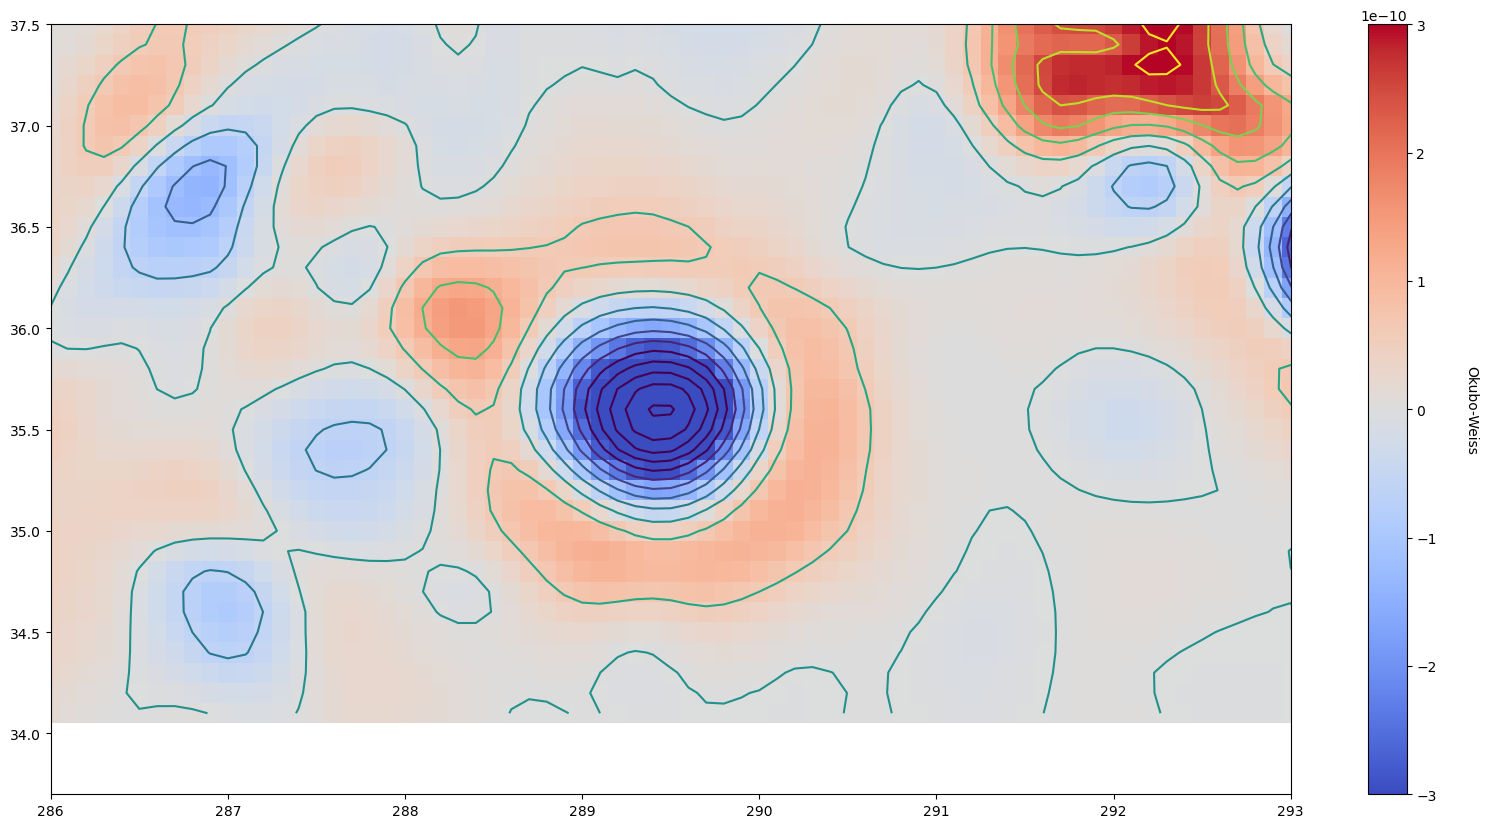

In [74]:
fig,ax=plt.subplots(figsize=(20,10))
plot = ax.pcolormesh(lon1d,lat1d,OkuboWeiss,cmap='coolwarm',vmin=-3e-10,vmax=3e-10)
cbar = plt.colorbar(plot,ax=ax)
cbar.set_label('Okubo-Weiss', rotation=270, labelpad=30)
contour_plot = ax.contour(lon1d, lat1d, OkuboWeiss,  20,
                               vmin=-3e-10, vmax=3e-10)

ax.set_xlim([jj,kk])
ax.set_ylim([j,k])

(33.7, 37.5)

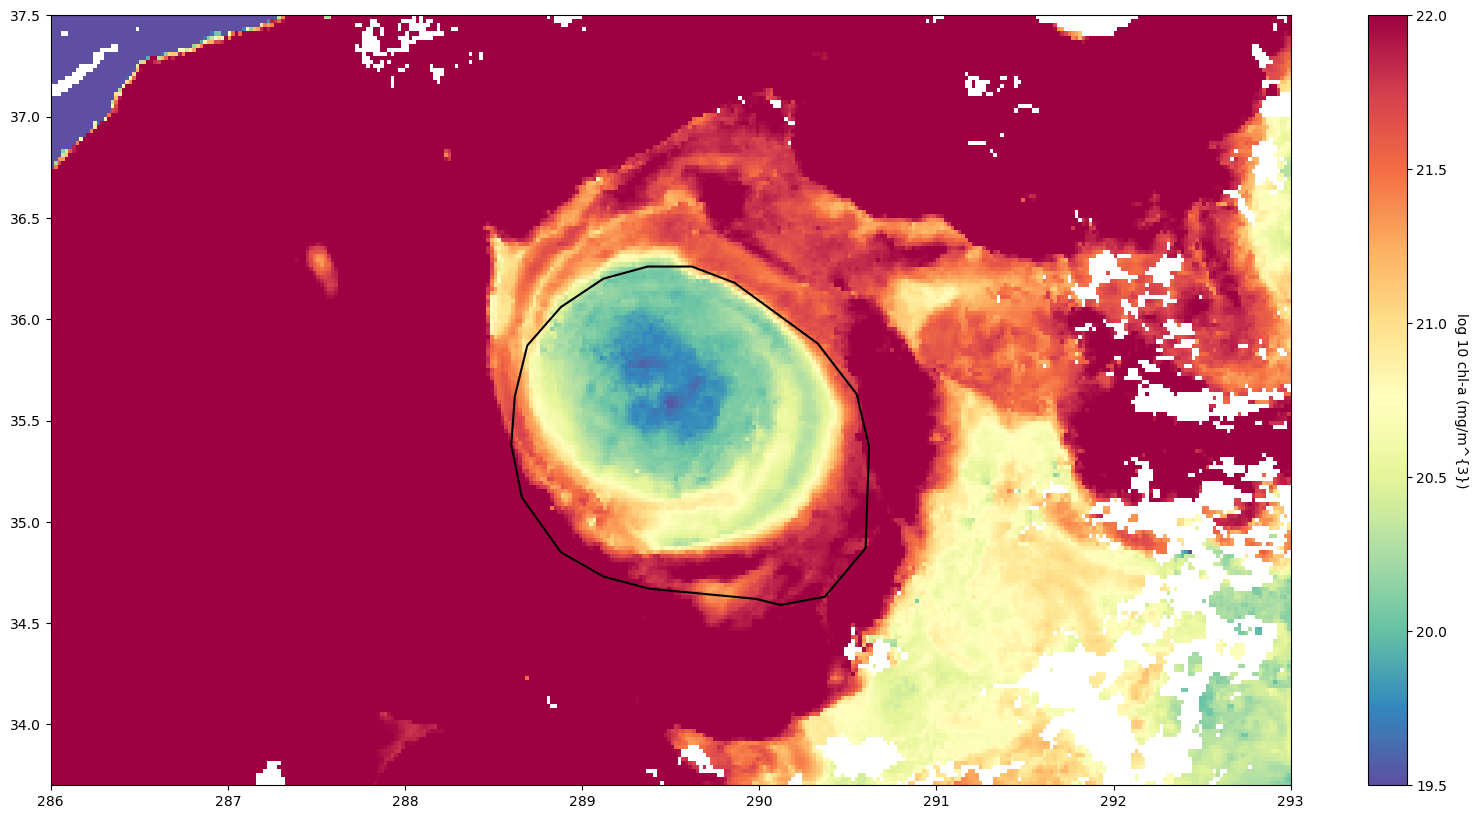

In [46]:
fig,ax=plt.subplots(figsize=(20,10))

plot = plt.pcolormesh(sstdata['lon']+360, sstdata['lat'],np.squeeze(sst),cmap='Spectral_r',vmin=19.5,vmax=22) #,vmin=18,vmax=22)#
cbar = plt.colorbar(plot)
cbar.set_label('log 10 chl-a (mg/m^{3})', rotation=270, labelpad=15)
ax.plot(contour_lons,contour_lats,color='black')
ax.set_xlim([jj,kk])
ax.set_ylim([j,k])

/tmp/ipykernel_1346/1551645511.py:3: UserWarning: The input coordinates to pcolor are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolor.
  plot = plt.pcolor(mlon,mlat,np.log10(chl),cmap='Spectral_r',vmin=-0.8,vmax=-0.5)
/tmp/ipykernel_1346/1551645511.py:4: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(plot)


(33.7, 37.5)

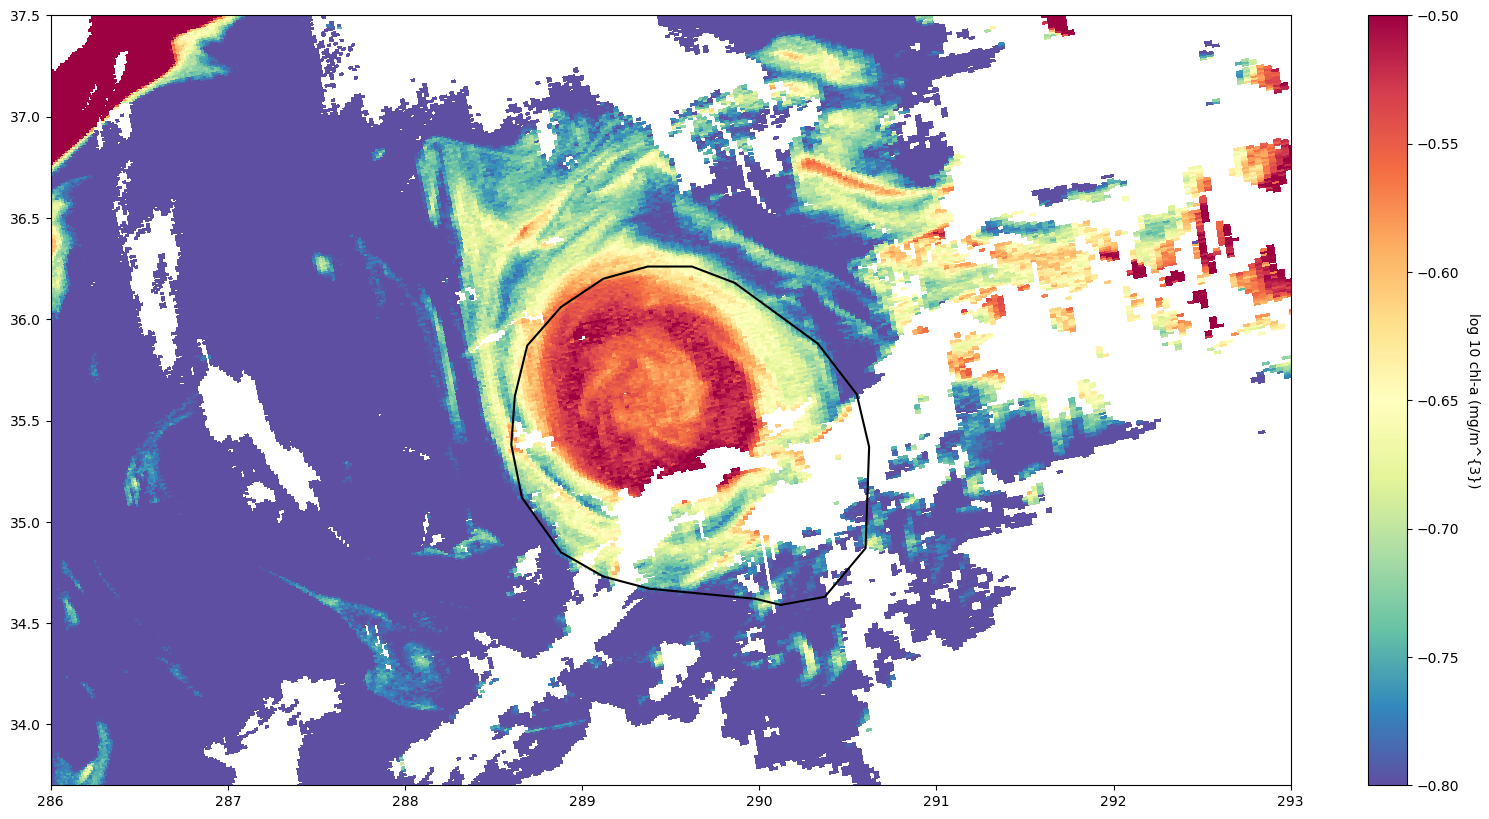

In [80]:
fig,ax=plt.subplots(figsize=(20,10))

plot = plt.pcolor(mlon,mlat,np.log10(chl),cmap='Spectral_r',vmin=-0.8,vmax=-0.5)
cbar = plt.colorbar(plot)
cbar.set_label('log 10 chl-a (mg/m^{3})', rotation=270, labelpad=15)
ax.plot(contour_lons,contour_lats,color='black')
ax.set_xlim([jj,kk])
ax.set_ylim([j,k])

/tmp/ipykernel_1346/599719705.py:3: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plot = plt.pcolormesh(mlon,mlat,np.log10(pro),cmap='viridis',vmin=5.1,vmax=5.5)#,vmin=0,vmax=80)


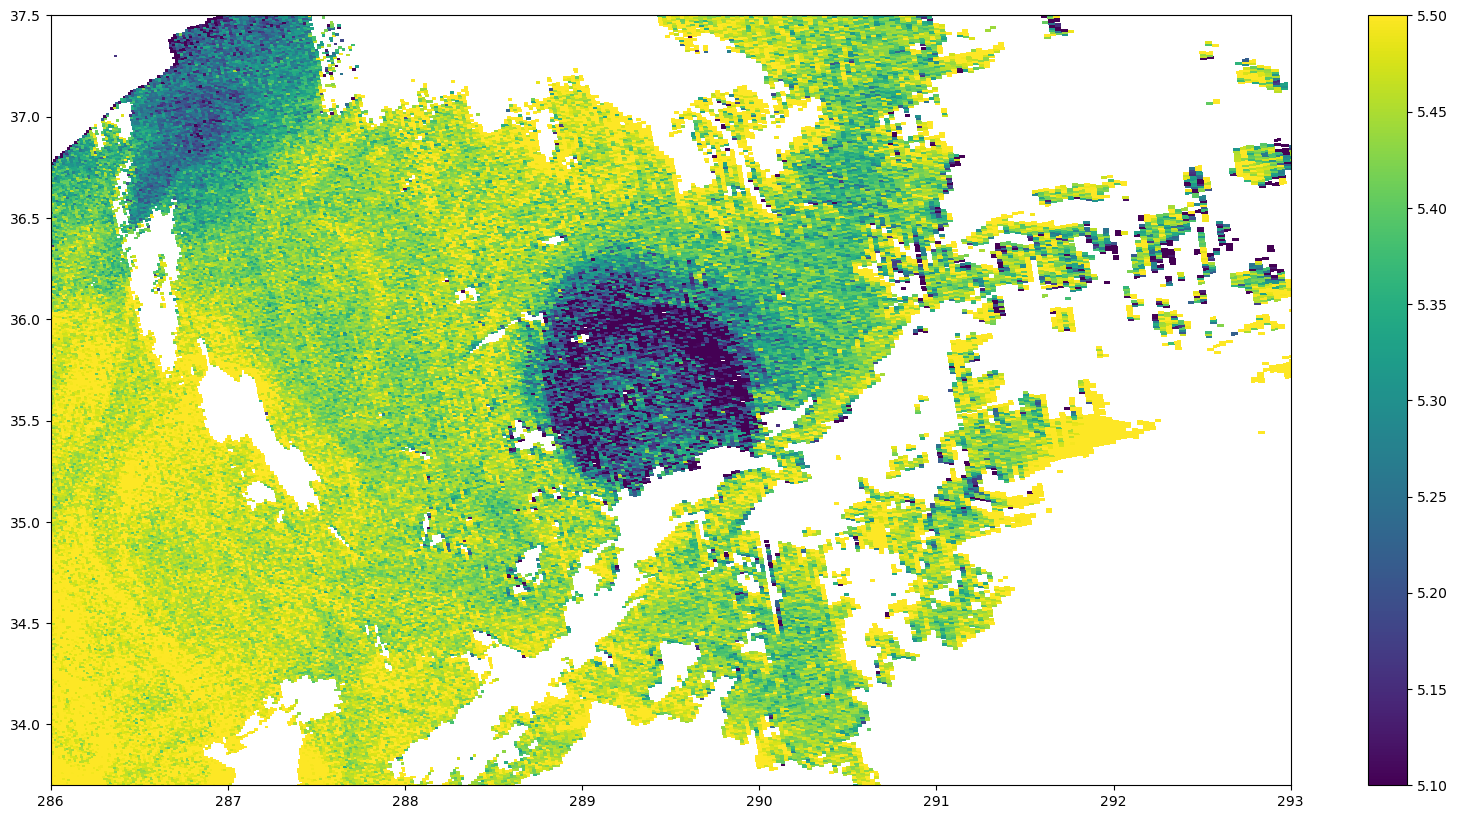

In [48]:
fig,ax=plt.subplots(figsize=(20,10))

plot = plt.pcolormesh(mlon,mlat,np.log10(pro),cmap='viridis',vmin=5.1,vmax=5.5)#,vmin=0,vmax=80)

ax.set_xlim([jj,kk])
ax.set_ylim([j,k])
cbar = plt.colorbar(plot)


/tmp/ipykernel_1346/3000313810.py:3: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plot = plt.pcolormesh(mlon,mlat,np.log10(syn),cmap='viridis',vmin=3.2,vmax=4)#,vmin=0,vmax=80)


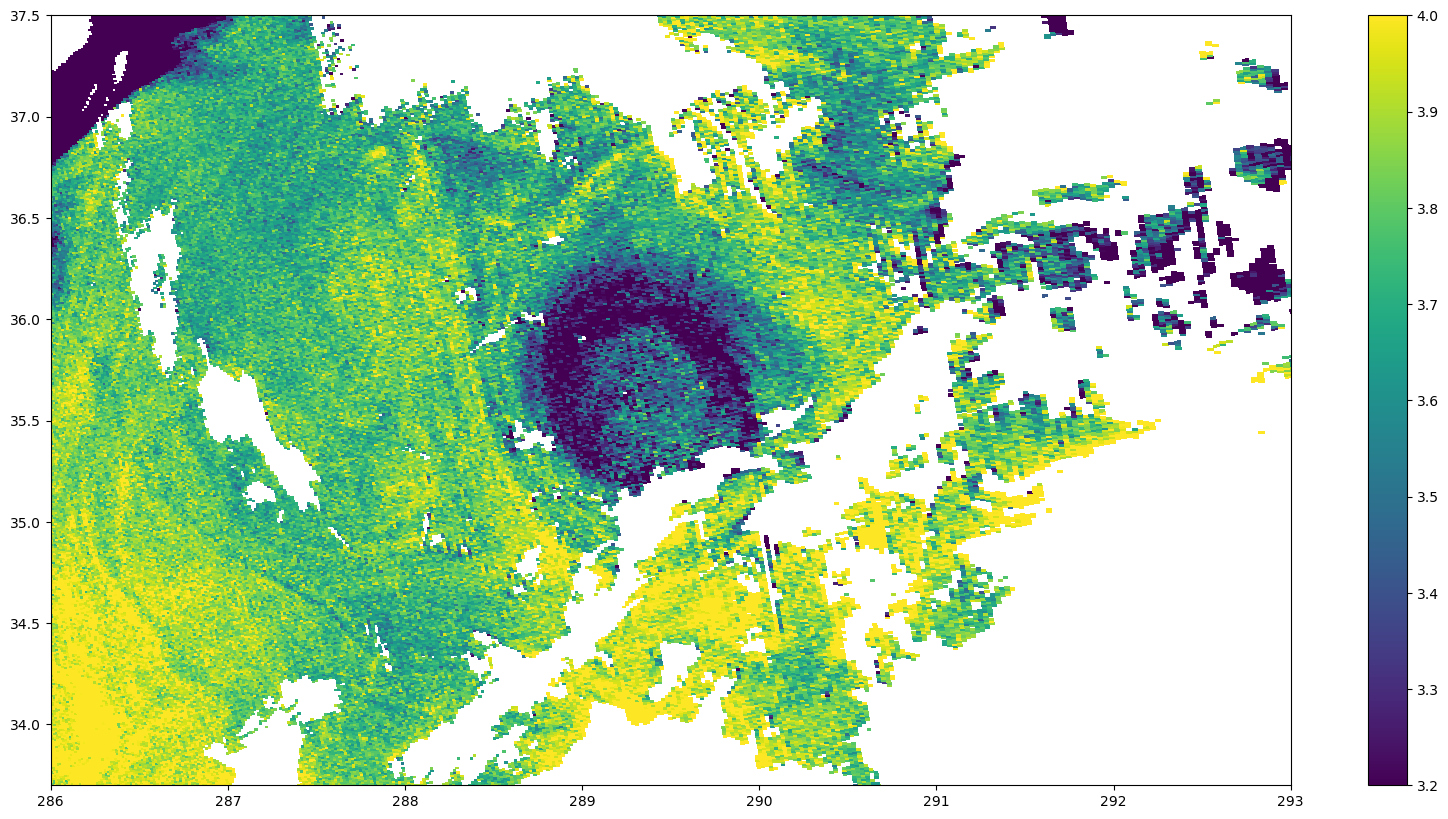

In [49]:
fig,ax=plt.subplots(figsize=(20,10))

plot = plt.pcolormesh(mlon,mlat,np.log10(syn),cmap='viridis',vmin=3.2,vmax=4)#,vmin=0,vmax=80)

ax.set_xlim([jj,kk])
ax.set_ylim([j,k])
cbar = plt.colorbar(plot)


# SWOT over NEUROST